In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import re
import os
from dotenv import load_dotenv

In [2]:
pd.set_option("display.max_columns", 100)
pd.set_option("display.max_rows", 100)

In [3]:
load_dotenv()
data_path = os.getenv("DATA_PATH")
path = os.path.join(data_path, r"raw\train_transaction.csv\train_transaction.csv")
train = pd.read_csv(path)

In [4]:
train.head()

,TransactionID,isFraud,TransactionDT,TransactionAmt,ProductCD,card1,card2,card3,card4,card5,card6,addr1,addr2,dist1,dist2,P_emaildomain,R_emaildomain,C1,C2,C3,C4,C5,C6,C7,C8,C9,C10,C11,C12,C13,C14,D1,D2,D3,D4,D5,D6,D7,D8,D9,D10,D11,D12,D13,D14,D15,M1,M2,M3,M4,...,V290,V291,V292,V293,V294,V295,V296,V297,V298,V299,V300,V301,V302,V303,V304,V305,V306,V307,V308,V309,V310,V311,V312,V313,V314,V315,V316,V317,V318,V319,V320,V321,V322,V323,V324,V325,V326,V327,V328,V329,V330,V331,V332,V333,V334,V335,V336,V337,V338,V339
0,2987000,0,86400,68.5,W,13926,NaN,150.0,discover,142.0,credit,315.0,87.0,19.0,NaN,NaN,NaN,1.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,2.0,0.0,1.0,1.0,14.0,NaN,13.0,NaN,NaN,NaN,NaN,NaN,NaN,13.0,13.0,NaN,NaN,NaN,0.0,T,T,T,M2,...,1.0,1.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,117.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,117.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2987001,0,86401,29.0,W,2755,404.0,150.0,mastercard,102.0,credit,325.0,87.0,NaN,NaN,gmail.com,NaN,1.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,1.0,0.0,NaN,NaN,0.0,NaN,NaN,NaN,NaN,NaN,0.0,NaN,NaN,NaN,NaN,0.0,NaN,NaN,NaN,M0,...,1.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2987002,0,86469,59.0,W,4663,490.0,150.0,visa,166.0,debit,330.0,87.0,287.0,NaN,outlook.com,NaN,1.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,1.0,0.0,NaN,NaN,0.0,NaN,NaN,NaN,NaN,NaN,0.0,315.0,NaN,NaN,NaN,315.0,T,T,T,M0,...,1.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2987003,0,86499,50.0,W,18132,567.0,150.0,mastercard,117.0,debit,476.0,87.0,NaN,NaN,yahoo.com,NaN,2.0,5.0,0.0,0.0,0.0,4.0,0.0,0.0,1.0,0.0,1.0,0.0,25.0,1.0,112.0,112.0,0.0,94.0,0.0,NaN,NaN,NaN,NaN,84.0,NaN,NaN,NaN,NaN,111.0,NaN,NaN,NaN,M0,...,1.0,1.0,1.0,1.0,38.0,24.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,50.0,1758.0,925.0,0.0,354.0,0.0,135.0,0.0,0.0,0.0,50.0,1404.0,790.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,2987004,0,86506,50.0,H,4497,514.0,150.0,mastercard,102.0,credit,420.0,87.0,NaN,NaN,gmail.com,NaN,1.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,1.0,0.0,1.0,1.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,1.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [5]:
train["TransactionAmt"].describe()

count    590540.000000
mean        135.027176
std         239.162522
min           0.251000
25%          43.321000
50%          68.769000
75%         125.000000
max       31937.391000
Name: TransactionAmt, dtype: float64

In [6]:
train.groupby("isFraud")["TransactionAmt"].describe()

,count,mean,std,min,25%,50%,75%,max
isFraud,,,,,,,,
0,569877.0,134.511665,239.395078,0.251,43.970,68.5,120.0,31937.391
1,20663.0,149.244779,232.212163,0.292,35.044,75.0,161.0,5191.000


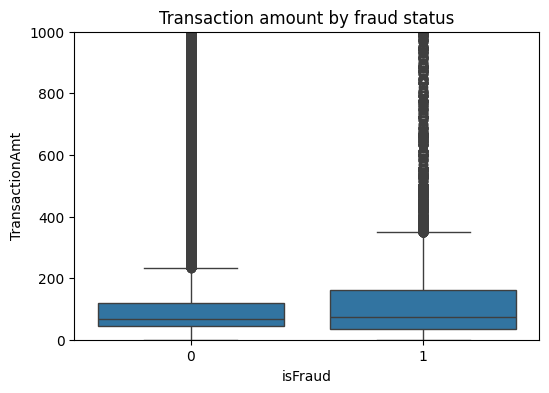

In [7]:
plt.figure(figsize=(6, 4))
sns.boxplot(data=train, x = "isFraud", y = "TransactionAmt")
plt.ylim(0, 1000)
plt.title("Transaction amount by fraud status")
plt.show()

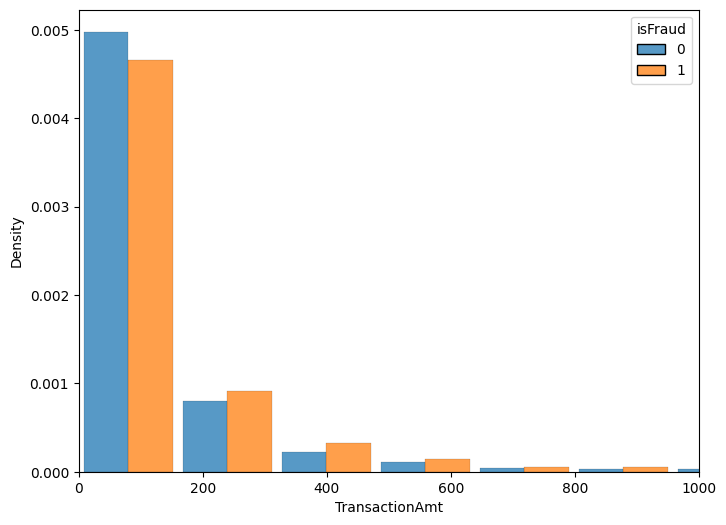

In [8]:
plt.figure(figsize=(8, 6))

sns.histplot(data = train, x='TransactionAmt', hue='isFraud', bins = 200, stat="density", common_norm=False, shrink=0.9, multiple="dodge")
plt.xlim(0, 1000)
plt.show()

In [40]:
def categoricl_fraud_rate(df, column):
    products_stats = (df.groupby(column)['isFraud'].agg(["mean", "count"]).rename(columns = {"mean": "fraud_rate"}))
    products_stats['fraud_rate'] = products_stats['fraud_rate'] * 100
    products_stats = products_stats.sort_values("fraud_rate", ascending=False)

    return products_stats

In [46]:
categoricl_fraud_rate(train, "P_emaildomain").head(20)

,fraud_rate,count
P_emaildomain,,
protonmail.com,40.789474,76
mail.com,18.962433,559
outlook.es,13.013699,438
aim.com,12.698413,315
outlook.com,9.458399,5096
hotmail.es,6.557377,305
live.com.mx,5.473965,749
hotmail.com,5.295028,45250
gmail.com,4.354185,228355


In [11]:
train["missing_count"] = train.isna().sum(axis=1)

In [12]:
train.groupby('isFraud')['missing_count'].describe()

,count,mean,std,min,25%,50%,75%,max
isFraud,,,,,,,,
0,569877.0,162.784041,38.384919,23.0,168.0,171.0,189.0,300.0
1,20663.0,135.498476,48.884864,24.0,77.0,121.0,173.0,281.0


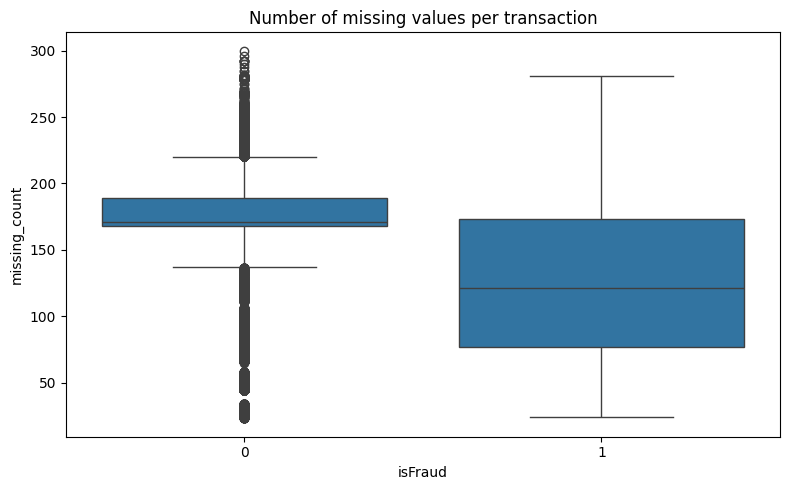

In [13]:
missing_stats = train.groupby('isFraud')['missing_count'].median()

plt.figure(figsize = (8, 5))

sns.boxplot(data = train, x = 'isFraud', y='missing_count')
plt.title("Number of missing values per transaction")
plt.tight_layout()
plt.show()

In [14]:
fraud_missing = train[train["isFraud"] == 1].isna().mean()
legit_missing = train[train["isFraud"] != 1].isna().mean()

In [15]:
missing_combined = pd.DataFrame({"fraud_missing": fraud_missing, "legit_missing": legit_missing})
missing_combined['difference'] = missing_combined['fraud_missing'] - missing_combined['legit_missing']
print(missing_combined.sort_values("difference", ascending=False).head(30))
print(missing_combined.sort_values("difference").head(50))

       fraud_missing  legit_missing  difference
M6          0.579345       0.276181    0.303164
addr2       0.374631       0.101715    0.272916
addr1       0.374631       0.101715    0.272916
M2          0.693075       0.450587    0.242488
M1          0.693075       0.450587    0.242488
M3          0.693075       0.450587    0.242488
V5          0.704496       0.464539    0.239957
V4          0.704496       0.464539    0.239957
V1          0.704496       0.464539    0.239957
V8          0.704496       0.464539    0.239957
V9          0.704496       0.464539    0.239957
V6          0.704496       0.464539    0.239957
V7          0.704496       0.464539    0.239957
V3          0.704496       0.464539    0.239957
V2          0.704496       0.464539    0.239957
D11         0.704496       0.464539    0.239957
V11         0.704496       0.464539    0.239957
V10         0.704496       0.464539    0.239957
M8          0.766878       0.579785    0.187093
M9          0.766878       0.579785    0

In [16]:
numeric_features = train.select_dtypes(include=["number"]).columns.tolist()
numeric_features = [col for col in numeric_features if col not in ("isFraud", "TransactionID")]
numeric_features[:5]        

['TransactionDT', 'TransactionAmt', 'card1', 'card2', 'card3']

In [17]:
feature_groups = {
    "C": [c for c in train.columns if c.startswith("C")],
    "D": [c for c in train.columns if c.startswith("D")],
    "V": [c for c in train.columns if c.startswith("V")],
    "M": [c for c in train.columns if c.startswith("M")],
    "card": [c for c in train.columns if c.startswith("card")],
    "addr": [c for c in train.columns if c.startswith("addr")],
    "dist": [c for c in train.columns if c.startswith("dist")],
}

In [19]:
number_of_instances_per_group = {group: len(columns) for group, columns in feature_groups.items()}

In [20]:
number_of_instances_per_group

{'C': 14, 'D': 15, 'V': 339, 'M': 9, 'card': 6, 'addr': 2, 'dist': 2}